# Assignment 3 – Climate Tweet Data Analysis with Visualization

**Objective:** This assignment demonstrates the application of data visualization concepts to analyze a dataset of climate-related tweets collected from different countries. Each row represents one tweet discussing a climate topic such as air quality, emissions, drought, renewable energy, or global warming.

**Dataset:** Climate_Tweets_Sample.csv

---

## Required Libraries

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


---
# Part A – Cleaning & Sentiment Overview (20 marks)

## A1) Loading the Dataset

In [2]:
# A1) Load the CSV file into a pandas DataFrame
df = pd.read_csv('Climate_Tweets_Sample.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 2000 rows × 8 columns


## A2) Initial Data Inspection

In [3]:
# A2) Show the first 5 rows of the dataset
df.head()

,tweet_id,date,country,sentiment,keyword,text,retweet_count,like_count
0,2803826677020224,2023-11-01,Denmark,negative,air quality,Breaking: concerns grow over air quality; data...,80.0,92.0
1,1119349365897942,2022-11-16,Spain,negative,air quality,Reminder: concerns grow over air quality; deta...,14.0,125.0
2,3605591970800719,2023-01-20,France,neutral,green transition,FYI: discussion continues on green transition;...,78.0,109.0
3,4546715437012377,2023-09-10,Saudi Arabia,negative,green transition,Opinion: concerns grow over green transition; ...,75.0,63.0
4,9630049315224554,2022-09-26,Ireland,negative,global warming,Opinion: global warming impacts are worsening;...,58.0,58.0


In [4]:
# Show data structure and types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   tweet_id       2000 non-null   int64  
 1   date           2000 non-null   object 
 2   country        2000 non-null   object 
 3   sentiment      2000 non-null   object 
 4   keyword        2000 non-null   object 
 5   text           2000 non-null   object 
 6   retweet_count  1962 non-null   float64
 7   like_count     1968 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 125.1+ KB


In [5]:
# Show summary statistics for all columns
df.describe(include='all')

,tweet_id,date,country,sentiment,keyword,text,retweet_count,like_count
count,2.000000e+03,2000,2000,2000,2000,2000,1962.000000,1968.000000
unique,NaN,915,39,3,14,1840,NaN,NaN
top,NaN,2021-07-21,New Zealand,negative,emissions,Report: encouraging signs for net zero; data a...,NaN,NaN
freq,NaN,8,69,736,158,4,NaN,NaN
mean,5.539795e+15,NaN,NaN,NaN,NaN,NaN,48.576962,100.227642
std,2.605952e+15,NaN,NaN,NaN,NaN,NaN,26.371671,56.965593
min,1.002787e+15,NaN,NaN,NaN,NaN,NaN,1.000000,2.000000
25%,3.343202e+15,NaN,NaN,NaN,NaN,NaN,27.000000,59.000000
50%,5.547012e+15,NaN,NaN,NaN,NaN,NaN,48.000000,98.000000
75%,7.797005e+15,NaN,NaN,NaN,NaN,NaN,69.000000,135.000000


---
## A3) Data Cleaning & Preparation

### A3.1) Date Parsing

In [6]:
# A3.1) Convert the date column to proper datetime format

# Create a copy to preserve original data
df_clean = df.copy()

# Parse date column to datetime
print(f"Original date dtype: {df_clean['date'].dtype}")
df_clean['date'] = pd.to_datetime(df_clean['date'])
print(f"Converted date dtype: {df_clean['date'].dtype}")

# Display date range
print(f"\nDate range: {df_clean['date'].min()} to {df_clean['date'].max()}")

Original date dtype: object
Converted date dtype: datetime64[ns]

Date range: 2021-01-03 00:00:00 to 2023-12-31 00:00:00


### A3.2) Duplicate Detection and Handling

In [7]:
# A3.2) Detect and remove duplicate tweets based on tweet_id

# Check for duplicate tweet_ids
duplicates_count = df_clean.duplicated(subset='tweet_id').sum()
print(f"Duplicate tweets found (by tweet_id): {duplicates_count}")

# Check for full row duplicates
full_duplicates = df_clean.duplicated().sum()
print(f"Full row duplicates: {full_duplicates}")

# Remove duplicates if any exist
if duplicates_count > 0:
    initial_rows = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset='tweet_id', keep='first')
    print(f"\nRemoved {initial_rows - len(df_clean)} duplicate rows")
    print(f"Rows after deduplication: {len(df_clean)}")
else:
    print("\nNo duplicate tweet_ids found - no action needed")

Duplicate tweets found (by tweet_id): 0
Full row duplicates: 0

No duplicate tweet_ids found - no action needed


### A3.3) Handling Missing Values

In [8]:
# A3.3) Handle missing values in retweet_count and like_count

# Check missing values across all columns
print("Missing values per column:")
print(df_clean.isnull().sum())
print(f"\nTotal missing values: {df_clean.isnull().sum().sum()}")

# Focus on numeric engagement columns
engagement_cols = ['retweet_count', 'like_count']
print(f"\nMissing values in engagement columns:")
for col in engagement_cols:
    missing = df_clean[col].isnull().sum()
    pct = (missing / len(df_clean)) * 100
    print(f"  {col}: {missing} ({pct:.2f}%)")

Missing values per column:
tweet_id          0
date              0
country           0
sentiment         0
keyword           0
text              0
retweet_count    38
like_count       32
dtype: int64

Total missing values: 70

Missing values in engagement columns:
  retweet_count: 38 (1.90%)
  like_count: 32 (1.60%)


In [9]:
# Apply median imputation for missing engagement values

print("JUSTIFICATION: Using MEDIAN IMPUTATION")
print("- Median is resistant to outliers (engagement metrics often have extreme values)")
print("- Retweet and like counts are typically right-skewed distributions")
print("- Missing values < 5% - deletion would unnecessarily reduce sample size")
print("- Missing pattern appears random (MAR - Missing At Random)")

# Apply median imputation
for col in engagement_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"\n{col}: Filled {df_clean[col].isnull().sum()} missing values with median = {median_val:.1f}")

print("\nMissing values after imputation:")
print(df_clean[engagement_cols].isnull().sum())

JUSTIFICATION: Using MEDIAN IMPUTATION
- Median is resistant to outliers (engagement metrics often have extreme values)
- Retweet and like counts are typically right-skewed distributions
- Missing values < 5% - deletion would unnecessarily reduce sample size
- Missing pattern appears random (MAR - Missing At Random)

retweet_count: Filled 0 missing values with median = 48.0

like_count: Filled 0 missing values with median = 98.0

Missing values after imputation:
retweet_count    0
like_count       0
dtype: int64


### A3.4) Data Cleaning Summary

In [10]:
# A3.4) Data cleaning summary

print("=" * 60)
print("DATA CLEANING SUMMARY")
print("=" * 60)
print(f"\nOriginal dataset shape: {df.shape}")
print(f"Cleaned dataset shape:  {df_clean.shape}")
print(f"\nCleaning steps performed:")
print("  1. Converted 'date' column to datetime format")
print("  2. Checked and handled duplicate tweet_ids")
print("  3. Imputed missing values in engagement columns using median")

print(f"\nFinal data types:")
print(df_clean.dtypes)

print(f"\nConfirm no missing values remain:")
print(df_clean.isnull().sum())

DATA CLEANING SUMMARY

Original dataset shape: (2000, 8)
Cleaned dataset shape:  (2000, 8)

Cleaning steps performed:
  1. Converted 'date' column to datetime format
  2. Checked and handled duplicate tweet_ids
  3. Imputed missing values in engagement columns using median

Final data types:
tweet_id                  int64
date             datetime64[ns]
country                  object
sentiment                object
keyword                  object
text                     object
retweet_count           float64
like_count              float64
dtype: object

Confirm no missing values remain:
tweet_id         0
date             0
country          0
sentiment        0
keyword          0
text             0
retweet_count    0
like_count       0
dtype: int64


---
## A4) Sentiment Visualization

### A4.1) Overall Sentiment Distribution

C:\Users\patel\AppData\Local\Temp\ipykernel_21860\1085524250.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([s.capitalize() for s in sentiment_order])


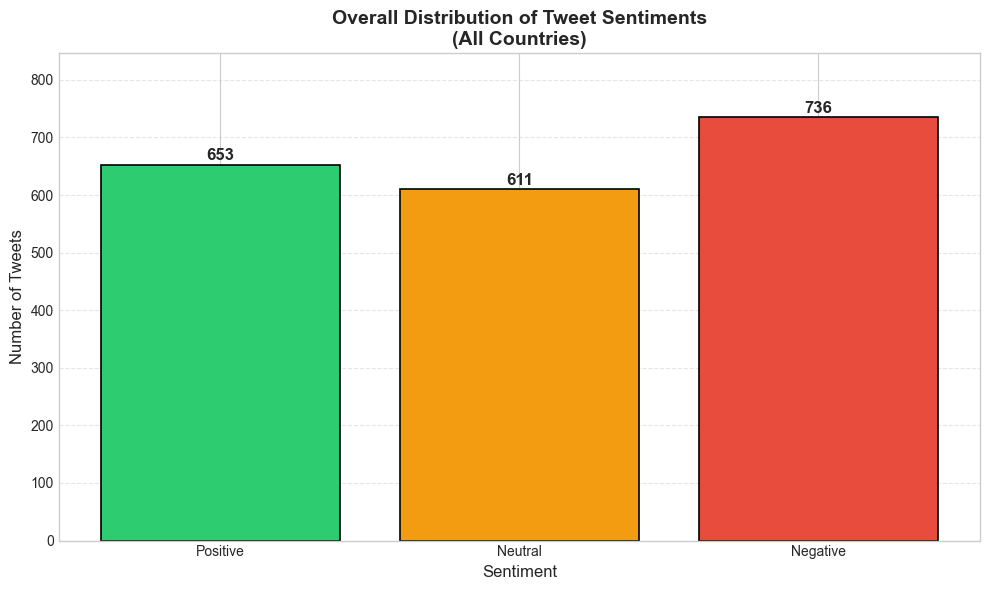


Sentiment Distribution Summary:
  Positive   :  653 tweets (32.6%)
  Neutral    :  611 tweets (30.6%)
  Negative   :  736 tweets (36.8%)


In [11]:
# A4.1) Bar chart showing overall distribution of tweet sentiments

# Count tweets by sentiment
sentiment_counts = df_clean['sentiment'].value_counts()

# Define colors for sentiment categories
sentiment_colors = {
    'positive': '#2ecc71',   # Green
    'neutral': '#f39c12',    # Orange/Yellow
    'negative': '#e74c3c'    # Red
}

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars in order: positive, neutral, negative
sentiment_order = ['positive', 'neutral', 'negative']
counts = [sentiment_counts.get(s, 0) for s in sentiment_order]
colors = [sentiment_colors[s] for s in sentiment_order]

bars = ax.bar(sentiment_order, counts, color=colors, edgecolor='black', linewidth=1.2)

# Add value labels on top of bars
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
            f'{count}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Customize chart
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Number of Tweets', fontsize=12)
ax.set_title('Overall Distribution of Tweet Sentiments\n(All Countries)', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(counts) * 1.15)  # Add space for labels
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

# Capitalize x-axis labels
ax.set_xticklabels([s.capitalize() for s in sentiment_order])

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSentiment Distribution Summary:")
for sentiment in sentiment_order:
    count = sentiment_counts.get(sentiment, 0)
    pct = (count / len(df_clean)) * 100
    print(f"  {sentiment.capitalize():10} : {count:4} tweets ({pct:.1f}%)")

### A4.2) Sentiment Distribution by Top 10 Countries

In [12]:
# A4.2) Identify top 10 countries by tweet count

# Get top 10 countries
country_counts = df_clean['country'].value_counts()
top_10_countries = country_counts.head(10).index.tolist()

print("Top 10 Countries by Tweet Count:")
for i, country in enumerate(top_10_countries, 1):
    count = country_counts[country]
    print(f"  {i:2}. {country:20} : {count} tweets")

Top 10 Countries by Tweet Count:
   1. New Zealand          : 69 tweets
   2. Thailand             : 68 tweets
   3. Mexico               : 67 tweets
   4. Spain                : 64 tweets
   5. Denmark              : 63 tweets
   6. Chile                : 60 tweets
   7. Saudi Arabia         : 59 tweets
   8. Peru                 : 58 tweets
   9. Italy                : 55 tweets
  10. Japan                : 55 tweets


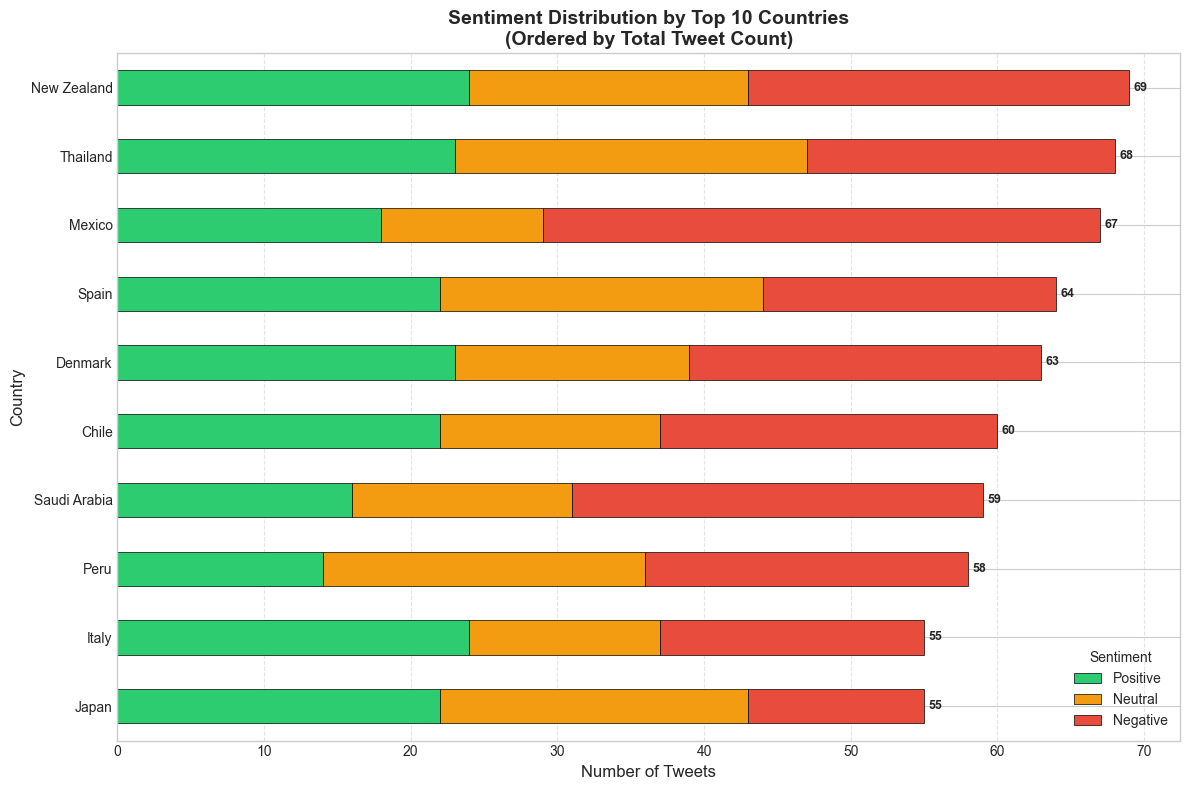

In [13]:
# A4.2) Visualize sentiment distribution across top 10 countries

# Filter data for top 10 countries
df_top10 = df_clean[df_clean['country'].isin(top_10_countries)]

# Create crosstab of country vs sentiment
sentiment_by_country = pd.crosstab(df_top10['country'], df_top10['sentiment'])

# Reorder columns to positive, neutral, negative
sentiment_order = ['positive', 'neutral', 'negative']
sentiment_by_country = sentiment_by_country.reindex(columns=sentiment_order, fill_value=0)

# Sort by total tweets (descending)
sentiment_by_country['total'] = sentiment_by_country.sum(axis=1)
sentiment_by_country = sentiment_by_country.sort_values('total', ascending=True)
sentiment_by_country = sentiment_by_country.drop('total', axis=1)

# Create horizontal stacked bar chart
fig, ax = plt.subplots(figsize=(12, 8))

# Define colors
colors = ['#2ecc71', '#f39c12', '#e74c3c']  # positive, neutral, negative

# Plot stacked horizontal bars
sentiment_by_country.plot(kind='barh', stacked=True, ax=ax, color=colors, edgecolor='black', linewidth=0.5)

# Customize chart
ax.set_xlabel('Number of Tweets', fontsize=12)
ax.set_ylabel('Country', fontsize=12)
ax.set_title('Sentiment Distribution by Top 10 Countries\n(Ordered by Total Tweet Count)', fontsize=14, fontweight='bold')

# Customize legend
ax.legend(title='Sentiment', labels=['Positive', 'Neutral', 'Negative'], 
          loc='lower right', fontsize=10)

# Add gridlines
ax.xaxis.grid(True, linestyle='--', alpha=0.5)

# Add total count labels at the end of each bar
for i, (country, row) in enumerate(sentiment_by_country.iterrows()):
    total = row.sum()
    ax.text(total + 0.3, i, f'{int(total)}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
## A5) Export Cleaned Data

In [14]:
# Export cleaned data to CSV
df_clean.to_csv('Climate_Tweets_Cleaned.csv', index=False)
print("✅ Cleaned data exported to: Climate_Tweets_Cleaned.csv")
print(f"   Shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")

✅ Cleaned data exported to: Climate_Tweets_Cleaned.csv
   Shape: 2000 rows × 8 columns


---
# Part B – Text Preprocessing & Word Cloud Analysis (25 marks)

## B1) Import Additional Libraries for Text Processing

In [15]:
# B1) Import libraries for text processing
import re
import string
from collections import Counter

# NLTK for stopwords and lemmatization
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# WordCloud for visualization
from wordcloud import WordCloud

print("Text processing libraries imported successfully!")
print(f"Stopwords available: {len(stopwords.words('english'))} English stopwords")

Text processing libraries imported successfully!
Stopwords available: 198 English stopwords


## B2) Text Preprocessing Pipeline

In [16]:
# B2) Define text preprocessing function

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Add custom stopwords specific to this dataset (common non-informative words)
custom_stopwords = {'rt', 'https', 'http', 'co', 'amp', 'via', 'like', 'get', 'got', 
                    'would', 'could', 'one', 'also', 'make', 'need', 'see', 'us',
                    'fyi', 'breaking', 'update', 'report', 'opinion', 'research',
                    'reminder', 'heads', 'check', 'figures', 'details', 'incoming',
                    'source', 'comments', 'data', 'attached', 'stay', 'informed',
                    'share', 'responsibly', 'learn', 'soon', 'think', 'new'}
stop_words.update(custom_stopwords)

def preprocess_text(text):
    """
    Preprocess tweet text with the following steps:
    1. Convert to lowercase
    2. Remove URLs
    3. Remove punctuation and special characters
    4. Remove numbers
    5. Tokenize into words
    6. Remove stopwords
    7. Apply lemmatization (reduce words to base form)
    
    Returns: cleaned text as a single string
    """
    if pd.isna(text):
        return ""
    
    # 1. Convert to lowercase
    text = text.lower()
    
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # 3. Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)
    
    # 4. Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # 5. Tokenize into words
    words = text.split()
    
    # 6. Remove stopwords and short words (< 3 characters)
    words = [word for word in words if word not in stop_words and len(word) >= 3]
    
    # 7. Apply lemmatization (reduces words to base form, e.g., "running" -> "run")
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return ' '.join(words)

print("Text preprocessing function defined!")
print("\nPreprocessing steps:")
print("  1. Lowercasing - normalize case for consistency")
print("  2. URL removal - remove http/https links")
print("  3. Punctuation removal - remove special characters")
print("  4. Number removal - remove numeric characters")
print("  5. Tokenization - split text into words")
print("  6. Stopword removal - remove common words (the, is, at, etc.)")
print("  7. Lemmatization - reduce words to base form (e.g., 'policies' → 'policy')")

Text preprocessing function defined!

Preprocessing steps:
  1. Lowercasing - normalize case for consistency
  2. URL removal - remove http/https links
  3. Punctuation removal - remove special characters
  4. Number removal - remove numeric characters
  5. Tokenization - split text into words
  6. Stopword removal - remove common words (the, is, at, etc.)
  7. Lemmatization - reduce words to base form (e.g., 'policies' → 'policy')


In [17]:
# Apply preprocessing to tweet text

# Create preprocessed text column
df_clean['text_clean'] = df_clean['text'].apply(preprocess_text)

# Show before and after examples
print("Text Preprocessing Examples:")
print("=" * 70)
for i in range(3):
    print(f"\nOriginal [{i+1}]: {df_clean['text'].iloc[i]}")
    print(f"Cleaned  [{i+1}]: {df_clean['text_clean'].iloc[i]}")
    print("-" * 70)

Text Preprocessing Examples:

Original [1]: Breaking: concerns grow over air quality; data attached.
Cleaned  [1]: concern grow air quality
----------------------------------------------------------------------

Original [2]: Reminder: concerns grow over air quality; details incoming.
Cleaned  [2]: concern grow air quality
----------------------------------------------------------------------

Original [3]: FYI: discussion continues on green transition; check the figures.
Cleaned  [3]: discussion continues green transition
----------------------------------------------------------------------


---
## B3) Keyword Analysis: Top 20 Most Frequent Terms

In [18]:
# B3) Identify and visualize top 20 most frequent terms

# Combine all cleaned text and split into words
all_words = ' '.join(df_clean['text_clean']).split()

# Count word frequencies
word_freq = Counter(all_words)
top_20_words = word_freq.most_common(20)

# Display top 20 words
print("Top 20 Most Frequent Terms in Climate Tweets:")
print("=" * 45)
for i, (word, count) in enumerate(top_20_words, 1):
    print(f"  {i:2}. {word:20} : {count:4} occurrences")

Top 20 Most Frequent Terms in Climate Tweets:
   1. policy               :  346 occurrences
   2. concern              :  207 occurrences
   3. grow                 :  207 occurrences
   4. alarm                :  181 occurrences
   5. raised               :  181 occurrences
   6. impact               :  179 occurrences
   7. worsening            :  179 occurrences
   8. boost                :  177 occurrences
   9. face                 :  169 occurrences
  10. setback              :  169 occurrences
  11. progress             :  169 occurrences
  12. promising            :  169 occurrences
  13. overview             :  167 occurrences
  14. trend                :  167 occurrences
  15. emission             :  158 occurrences
  16. net                  :  157 occurrences
  17. zero                 :  157 occurrences
  18. global               :  156 occurrences
  19. warming              :  156 occurrences
  20. community            :  154 occurrences


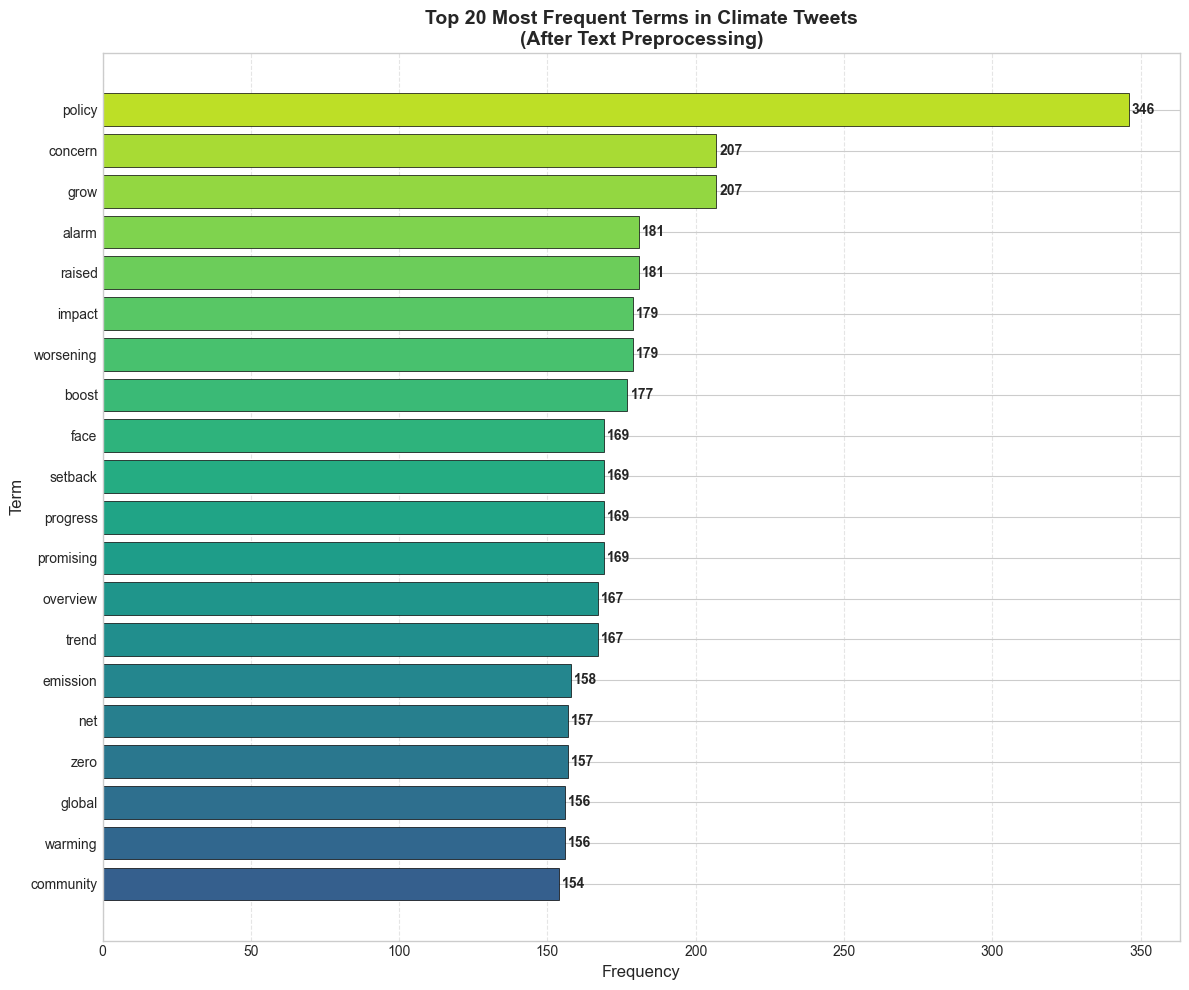

In [19]:
# Visualize top 20 terms as horizontal bar chart

fig, ax = plt.subplots(figsize=(12, 10))

# Prepare data for plotting
words = [word for word, count in top_20_words]
counts = [count for word, count in top_20_words]

# Reverse for horizontal bar (highest at top)
words = words[::-1]
counts = counts[::-1]

# Create gradient colors
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(words)))

# Plot horizontal bar chart
bars = ax.barh(words, counts, color=colors, edgecolor='black', linewidth=0.5)

# Add value labels
for bar, count in zip(bars, counts):
    ax.text(count + 1, bar.get_y() + bar.get_height()/2, f'{count}',
            va='center', fontsize=10, fontweight='bold')

# Customize chart
ax.set_xlabel('Frequency', fontsize=12)
ax.set_ylabel('Term', fontsize=12)
ax.set_title('Top 20 Most Frequent Terms in Climate Tweets\n(After Text Preprocessing)', 
             fontsize=14, fontweight='bold')
ax.xaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## B4) Word Cloud Analysis by Sentiment

Positive tweets count: 653
Total words in positive tweets: 2356


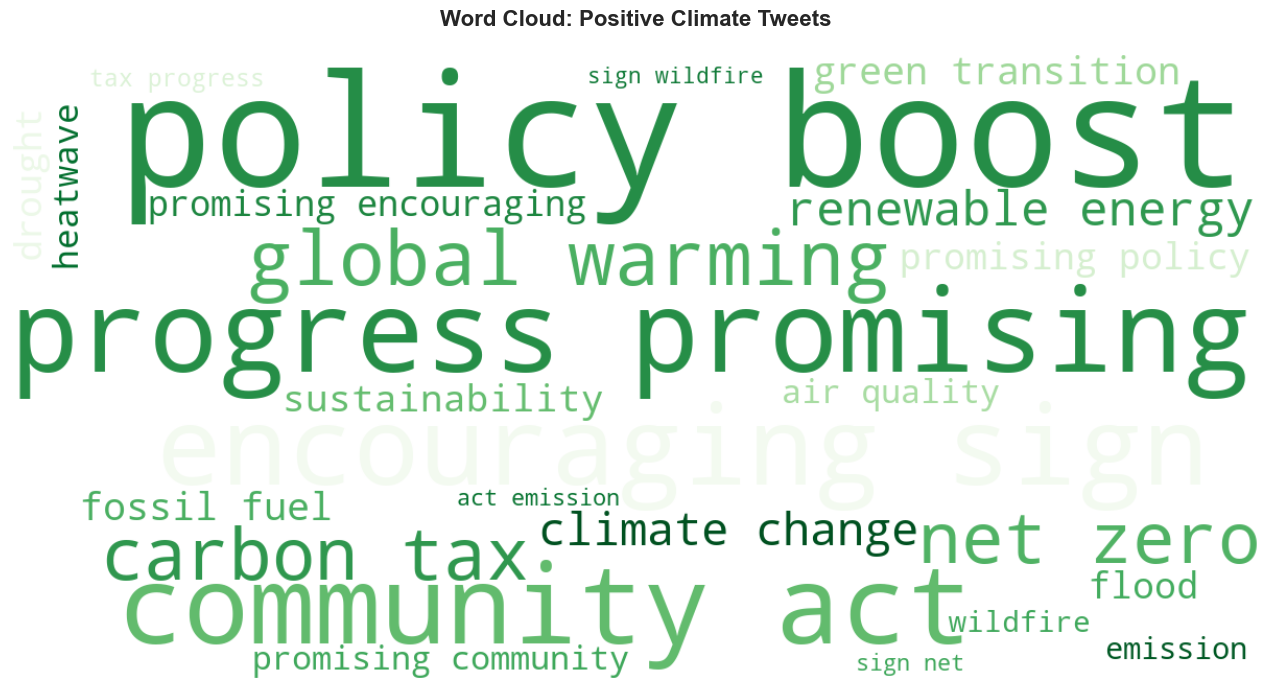

In [20]:
# B4.1) Word Cloud for Positive Tweets

# Filter positive tweets and combine text
positive_text = ' '.join(df_clean[df_clean['sentiment'] == 'positive']['text_clean'])

print(f"Positive tweets count: {len(df_clean[df_clean['sentiment'] == 'positive'])}")
print(f"Total words in positive tweets: {len(positive_text.split())}")

# Generate word cloud for positive tweets
wordcloud_positive = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='Greens',
    max_words=100,
    min_font_size=10,
    max_font_size=150,
    random_state=42
).generate(positive_text)

# Plot word cloud
fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wordcloud_positive, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud: Positive Climate Tweets', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

Negative tweets count: 736
Total words in negative tweets: 2793


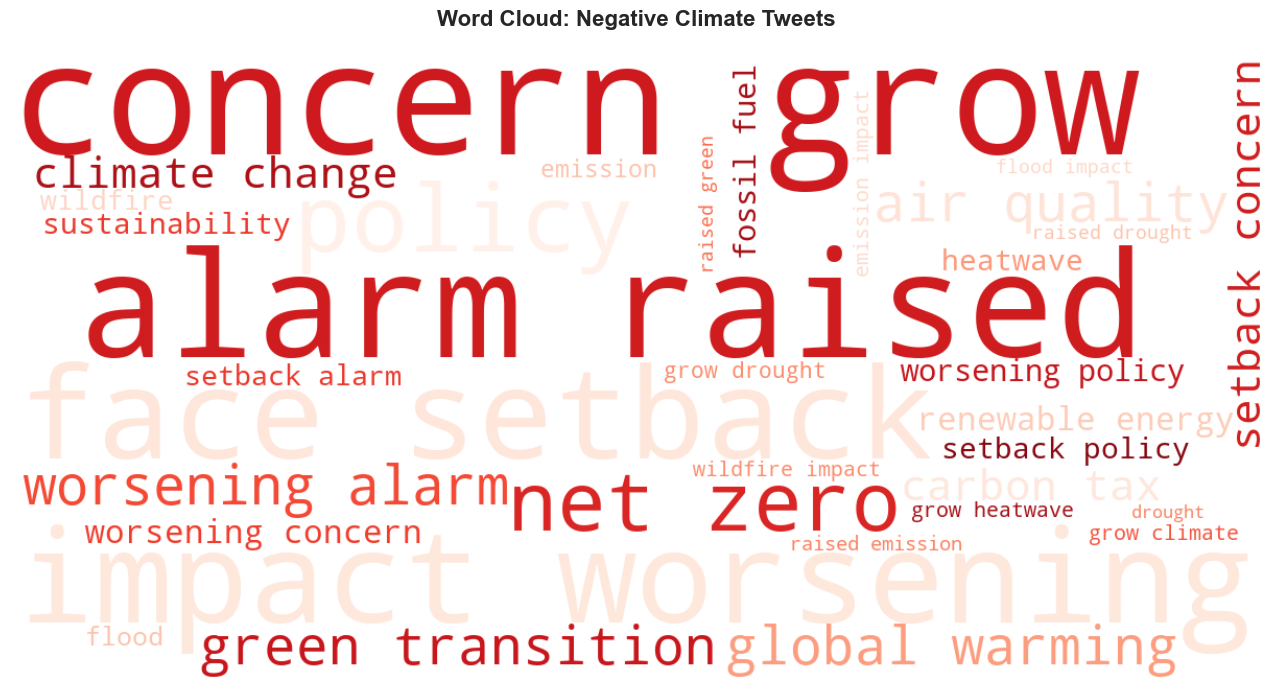

In [21]:
# B4.2) Word Cloud for Negative Tweets

# Filter negative tweets and combine text
negative_text = ' '.join(df_clean[df_clean['sentiment'] == 'negative']['text_clean'])

print(f"Negative tweets count: {len(df_clean[df_clean['sentiment'] == 'negative'])}")
print(f"Total words in negative tweets: {len(negative_text.split())}")

# Generate word cloud for negative tweets
wordcloud_negative = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='Reds',
    max_words=100,
    min_font_size=10,
    max_font_size=150,
    random_state=42
).generate(negative_text)

# Plot word cloud
fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wordcloud_negative, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud: Negative Climate Tweets', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

---
# Part C – Geospatial Visualization (15 marks)

## C1) Import Geospatial Libraries

In [23]:
# C1) Import Plotly for interactive choropleth map
import plotly.express as px
import plotly.graph_objects as go

print("Plotly imported successfully for geospatial visualization!")

Plotly imported successfully for geospatial visualization!


## C2) Handle Country Name Inconsistencies

In [41]:
# C2) Check current country names and identify inconsistencies

# Display unique countries in the dataset
print("Countries in the dataset:")
print("=" * 50)
countries = df_clean['country'].unique()
print(f"Total unique countries: {len(countries)}")
print(f"\nCountry list:")
for i, country in enumerate(sorted(countries), 1):
    print(f"  {i:2}. {country}")

Countries in the dataset:
Total unique countries: 39

Country list:
   1. Argentina
   2. Australia
   3. Brazil
   4. Canada
   5. Chile
   6. China
   7. Colombia
   8. Denmark
   9. Egypt
  10. France
  11. Germany
  12. Greece
  13. India
  14. Indonesia
  15. Ireland
  16. Italy
  17. Japan
  18. Mexico
  19. Netherlands
  20. New Zealand
  21. Nigeria
  22. Norway
  23. Pakistan
  24. Peru
  25. Philippines
  26. Poland
  27. Portugal
  28. Russia
  29. Saudi Arabia
  30. Singapore
  31. South Africa
  32. Spain
  33. Sweden
  34. Thailand
  35. Turkey
  36. United Arab Emirates
  37. United Kingdom
  38. United States
  39. Vietnam


In [42]:
# C2) Standardize country names to match ISO standards for Plotly choropleth

# Create mapping for country name standardization
# Maps dataset country names → ISO standard names used by Plotly
country_name_mapping = {
    # Standard names (no change needed)
    'Argentina': 'Argentina',
    'Australia': 'Australia',
    'Brazil': 'Brazil',
    'Canada': 'Canada',
    'China': 'China',
    'Colombia': 'Colombia',
    'Denmark': 'Denmark',
    'Egypt': 'Egypt',
    'France': 'France',
    'Germany': 'Germany',
    'Greece': 'Greece',
    'India': 'India',
    'Indonesia': 'Indonesia',
    'Ireland': 'Ireland',
    'Italy': 'Italy',
    'Japan': 'Japan',
    'Mexico': 'Mexico',
    'Netherlands': 'Netherlands',
    'New Zealand': 'New Zealand',
    'Nigeria': 'Nigeria',
    'Norway': 'Norway',
    'Pakistan': 'Pakistan',
    'Peru': 'Peru',
    'Philippines': 'Philippines',
    'Poland': 'Poland',
    'Portugal': 'Portugal',
    'Saudi Arabia': 'Saudi Arabia',
    'Singapore': 'Singapore',
    'Spain': 'Spain',
    'Sweden': 'Sweden',
    'Thailand': 'Thailand',
    'Turkey': 'Turkey',
    'Vietnam': 'Vietnam',
    # Names that may need standardization
    'United States': 'United States of America',
    'United Arab Emirates': 'United Arab Emirates',
    'UK': 'United Kingdom',
    'USA': 'United States of America',
    'U.S.': 'United States of America',
    'U.S.A.': 'United States of America',
}

# Apply country name standardization
df_clean['country_std'] = df_clean['country'].map(country_name_mapping).fillna(df_clean['country'])

# Check for any unmapped countries
unmapped = df_clean[df_clean['country'] != df_clean['country_std']][['country', 'country_std']].drop_duplicates()
if len(unmapped) > 0:
    print("Country names standardized:")
    print(unmapped.to_string(index=False))
else:
    print("All country names already in standard format")

print(f"\nStandardized countries: {df_clean['country_std'].nunique()} unique")

Country names standardized:
      country              country_std
United States United States of America

Standardized countries: 39 unique


## C3) Aggregate Tweet Data by Country

In [43]:
# C3) Aggregate tweet statistics by country

# Group by standardized country name and calculate metrics
country_stats = df_clean.groupby('country_std').agg({
    'tweet_id': 'count',                    # Total tweets
    'retweet_count': 'sum',                 # Total retweets
    'like_count': 'sum',                    # Total likes
    'sentiment': lambda x: (x == 'positive').sum()  # Positive tweet count
}).reset_index()

# Rename columns for clarity
country_stats.columns = ['country', 'tweet_count', 'total_retweets', 'total_likes', 'positive_count']

# Calculate additional metrics
country_stats['total_engagement'] = country_stats['total_retweets'] + country_stats['total_likes']
country_stats['avg_engagement'] = (country_stats['total_engagement'] / country_stats['tweet_count']).round(1)
country_stats['positive_ratio'] = (country_stats['positive_count'] / country_stats['tweet_count'] * 100).round(1)

# Sort by tweet count
country_stats = country_stats.sort_values('tweet_count', ascending=False)

print("Country-Level Tweet Statistics:")
print("=" * 90)
print(country_stats.to_string(index=False))
print(f"\nTotal: {country_stats['tweet_count'].sum()} tweets across {len(country_stats)} countries")

Country-Level Tweet Statistics:
                 country  tweet_count  total_retweets  total_likes  positive_count  total_engagement  avg_engagement  positive_ratio
             New Zealand           69          3447.0       7061.0              24           10508.0           152.3            34.8
                Thailand           68          3216.0       7205.0              23           10421.0           153.2            33.8
                  Mexico           67          3335.0       6775.0              18           10110.0           150.9            26.9
                   Spain           64          2972.0       7385.0              22           10357.0           161.8            34.4
                 Denmark           63          3090.0       6415.0              23            9505.0           150.9            36.5
                   Chile           60          3049.0       5709.0              22            8758.0           146.0            36.7
            Saudi Arabia           59

## C4) Choropleth Map: Tweet Volume by Country

In [44]:
# C4) Create choropleth map showing tweet volume by country

fig = px.choropleth(
    country_stats,
    locations='country',
    locationmode='country names',
    color='tweet_count',
    hover_name='country',
    hover_data={
        'tweet_count': True,
        'total_engagement': True,
        'avg_engagement': True,
        'positive_ratio': ':.1f'
    },
    color_continuous_scale='Blues',
    labels={
        'tweet_count': 'Tweet Count',
        'total_engagement': 'Total Engagement',
        'avg_engagement': 'Avg Engagement',
        'positive_ratio': 'Positive %'
    },
    title='Climate Tweet Volume by Country'
)

# Update layout for better visualization
fig.update_layout(
    title={
        'text': 'Climate Tweet Volume by Country<br><sup>Choropleth Map of Tweet Distribution</sup>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18, 'family': 'Arial', 'color': 'black'}
    },
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='gray',
        projection_type='natural earth',
        showland=True,
        landcolor='lightgray',
        showocean=True,
        oceancolor='lightblue',
        showcountries=True,
        countrycolor='white'
    ),
    coloraxis_colorbar=dict(
        title=dict(text='Tweet Count', side='right'),
        ticks='outside',
        ticklen=5,
        len=0.8
    ),
    margin=dict(l=0, r=0, t=80, b=0),
    height=600
)

fig.show()

print("\nChoropleth Map Legend:")
print("- Darker blue = Higher tweet volume")
print("- Lighter blue = Lower tweet volume")
print("- Gray = No data available")

C:\Users\patel\AppData\Local\Temp\ipykernel_21860\2911409035.py:3: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(



Choropleth Map Legend:
- Darker blue = Higher tweet volume
- Lighter blue = Lower tweet volume
- Gray = No data available


In [45]:
# C4) Additional: Choropleth map showing average engagement by country

fig2 = px.choropleth(
    country_stats,
    locations='country',
    locationmode='country names',
    color='avg_engagement',
    hover_name='country',
    hover_data={
        'tweet_count': True,
        'avg_engagement': ':.1f',
        'total_engagement': True,
        'positive_ratio': ':.1f'
    },
    color_continuous_scale='Viridis',
    labels={
        'tweet_count': 'Tweet Count',
        'avg_engagement': 'Avg Engagement',
        'total_engagement': 'Total Engagement',
        'positive_ratio': 'Positive %'
    },
    title='Average Tweet Engagement by Country'
)

# Update layout
fig2.update_layout(
    title={
        'text': 'Average Tweet Engagement by Country<br><sup>Average Likes + Retweets per Tweet</sup>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18, 'family': 'Arial', 'color': 'black'}
    },
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='gray',
        projection_type='natural earth',
        showland=True,
        landcolor='lightgray',
        showocean=True,
        oceancolor='lightblue',
        showcountries=True,
        countrycolor='white'
    ),
    coloraxis_colorbar=dict(
        title=dict(text='Avg Engagement', side='right'),
        ticks='outside',
        ticklen=5,
        len=0.8
    ),
    margin=dict(l=0, r=0, t=80, b=0),
    height=600
)

fig2.show()

print("\nEngagement Map Legend:")
print("- Yellow/Green = Higher average engagement")
print("- Purple/Blue = Lower average engagement")
print("- Gray = No data available")

C:\Users\patel\AppData\Local\Temp\ipykernel_21860\1959632809.py:3: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig2 = px.choropleth(



Engagement Map Legend:
- Yellow/Green = Higher average engagement
- Purple/Blue = Lower average engagement
- Gray = No data available


In [46]:
# C4) Summary of Geospatial Analysis

print("=" * 70)
print("GEOSPATIAL ANALYSIS SUMMARY")
print("=" * 70)

# Top 5 countries by volume
print("\nTop 5 Countries by Tweet Volume:")
for i, row in country_stats.head(5).iterrows():
    print(f"  {row['country']:25} : {int(row['tweet_count']):3} tweets")

# Top 5 countries by engagement
top_engagement = country_stats.nlargest(5, 'avg_engagement')
print("\nTop 5 Countries by Average Engagement:")
for i, row in top_engagement.iterrows():
    print(f"  {row['country']:25} : {row['avg_engagement']:.1f} avg engagement")

# Geographic coverage
print(f"\nGeographic Coverage:")
print(f"  Total countries represented: {len(country_stats)}")
print(f"  Continents covered: Multiple (Europe, Asia, Americas, Africa, Oceania)")

GEOSPATIAL ANALYSIS SUMMARY

Top 5 Countries by Tweet Volume:
  New Zealand               :  69 tweets
  Thailand                  :  68 tweets
  Mexico                    :  67 tweets
  Spain                     :  64 tweets
  Denmark                   :  63 tweets

Top 5 Countries by Average Engagement:
  Singapore                 : 170.9 avg engagement
  United Kingdom            : 162.5 avg engagement
  Spain                     : 161.8 avg engagement
  Greece                    : 155.6 avg engagement
  Germany                   : 155.2 avg engagement

Geographic Coverage:
  Total countries represented: 39
  Continents covered: Multiple (Europe, Asia, Americas, Africa, Oceania)


In [47]:
# D1) Define Wilson Score Interval function for proportion confidence intervals

from scipy import stats

def wilson_ci(successes, n, confidence=0.95):
    """
    Calculate Wilson Score Confidence Interval for a proportion.
    
    Parameters:
    -----------
    successes : int
        Number of successes (e.g., negative tweets)
    n : int
        Total sample size
    confidence : float
        Confidence level (default 0.95 for 95% CI)
    
    Returns:
    --------
    tuple: (proportion, lower_bound, upper_bound)
    """
    if n == 0:
        return (0, 0, 0)
    
    p_hat = successes / n
    z = stats.norm.ppf(1 - (1 - confidence) / 2)  # z = 1.96 for 95% CI
    
    # Wilson Score Interval formula
    denominator = 1 + (z**2 / n)
    center = (p_hat + z**2 / (2 * n)) / denominator
    margin = (z / denominator) * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))
    
    lower = max(0, center - margin)  # Ensure >= 0
    upper = min(1, center + margin)  # Ensure <= 1
    
    return (p_hat, lower, upper)

print("Wilson Score Interval function defined!")
print("\nKey advantages over Normal approximation:")
print("  1. Always produces valid intervals [0, 1]")
print("  2. Better coverage for small samples")
print("  3. Appropriate for extreme proportions")

Wilson Score Interval function defined!

Key advantages over Normal approximation:
  1. Always produces valid intervals [0, 1]
  2. Better coverage for small samples
  3. Appropriate for extreme proportions


## D2) Calculate Monthly Negative Sentiment Rate

In [48]:
# D2) Extract year-month and calculate monthly negative sentiment statistics

# Create year-month column for grouping
df_clean['year_month'] = df_clean['date'].dt.to_period('M')

# Aggregate monthly statistics
monthly_stats = df_clean.groupby('year_month').agg({
    'tweet_id': 'count',                              # Total tweets
    'sentiment': lambda x: (x == 'negative').sum()    # Negative tweet count
}).reset_index()

monthly_stats.columns = ['year_month', 'total_tweets', 'negative_count']

# Calculate negative rate and 95% CI using Wilson Score Interval
ci_results = monthly_stats.apply(
    lambda row: wilson_ci(row['negative_count'], row['total_tweets']),
    axis=1
)

monthly_stats['negative_rate'] = [r[0] for r in ci_results]
monthly_stats['ci_lower'] = [r[1] for r in ci_results]
monthly_stats['ci_upper'] = [r[2] for r in ci_results]

# Convert period to datetime for plotting
monthly_stats['date'] = monthly_stats['year_month'].dt.to_timestamp()

# Display the monthly statistics
print("Monthly Negative Sentiment Rate with 95% Wilson CI:")
print("=" * 80)
print(monthly_stats[['year_month', 'total_tweets', 'negative_count', 
                      'negative_rate', 'ci_lower', 'ci_upper']].to_string(index=False))
print(f"\nTotal months analyzed: {len(monthly_stats)}")

Monthly Negative Sentiment Rate with 95% Wilson CI:
year_month  total_tweets  negative_count  negative_rate  ci_lower  ci_upper
   2021-01            40               8       0.200000  0.105000  0.347573
   2021-02            46              18       0.391304  0.263932  0.535432
   2021-03            62              19       0.306452  0.205816  0.429672
   2021-04            45              14       0.311111  0.195287  0.456648
   2021-05            58              16       0.275862  0.177524  0.402047
   2021-06            56              20       0.357143  0.244566  0.488061
   2021-07            62              31       0.500000  0.379227  0.620773
   2021-08            62              26       0.419355  0.304776  0.543344
   2021-09            52              14       0.269231  0.167690  0.402522
   2021-10            53              23       0.433962  0.309504  0.567346
   2021-11            55              25       0.454545  0.330253  0.584773
   2021-12            62            

## D3) Time-Series Visualization with Confidence Intervals

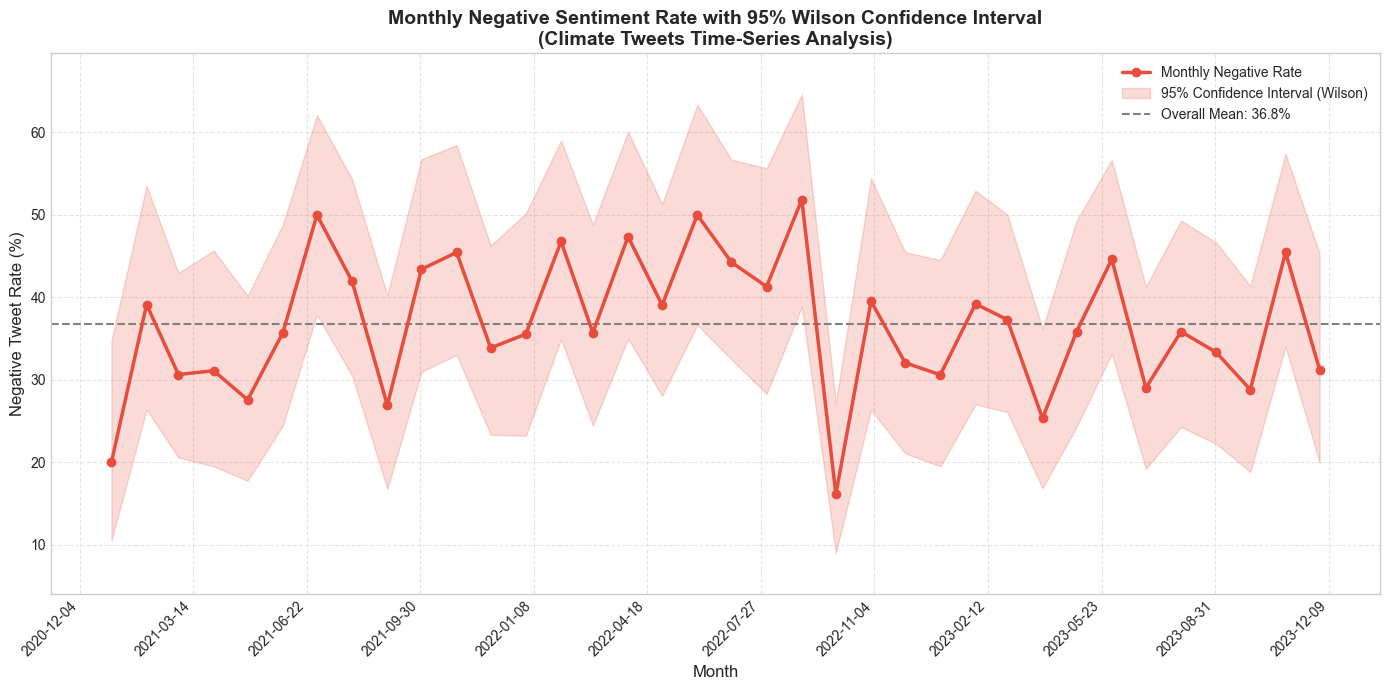

In [49]:
# D3) Create time-series visualization with 95% confidence intervals

fig, ax = plt.subplots(figsize=(14, 7))

# Plot the negative rate line
ax.plot(monthly_stats['date'], monthly_stats['negative_rate'] * 100, 
        color='#e74c3c', linewidth=2.5, marker='o', markersize=6,
        label='Monthly Negative Rate', zorder=3)

# Fill the confidence interval band
ax.fill_between(monthly_stats['date'], 
                monthly_stats['ci_lower'] * 100, 
                monthly_stats['ci_upper'] * 100,
                color='#e74c3c', alpha=0.2, 
                label='95% Confidence Interval (Wilson)')

# Add horizontal line for overall mean
overall_negative_rate = df_clean['sentiment'].value_counts(normalize=True).get('negative', 0) * 100
ax.axhline(y=overall_negative_rate, color='gray', linestyle='--', linewidth=1.5,
           label=f'Overall Mean: {overall_negative_rate:.1f}%')

# Customize the chart
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Negative Tweet Rate (%)', fontsize=12)
ax.set_title('Monthly Negative Sentiment Rate with 95% Wilson Confidence Interval\n(Climate Tweets Time-Series Analysis)', 
             fontsize=14, fontweight='bold')

# Format x-axis dates
ax.xaxis.set_major_locator(plt.MaxNLocator(12))
plt.xticks(rotation=45, ha='right')

# Add gridlines
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Legend
ax.legend(loc='upper right', fontsize=10)

# Set y-axis limits with padding
y_min = max(0, monthly_stats['ci_lower'].min() * 100 - 5)
y_max = min(100, monthly_stats['ci_upper'].max() * 100 + 5)
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

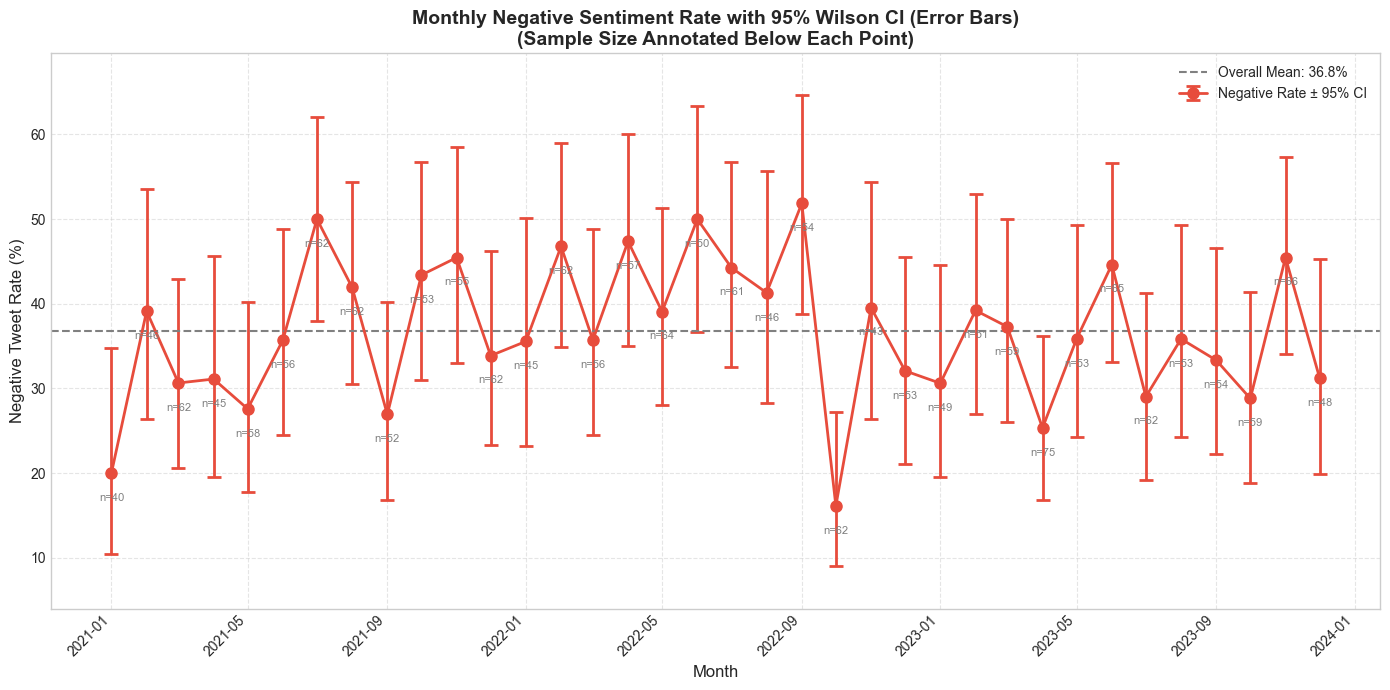

In [50]:
# D3) Alternative visualization: Error bar plot for clearer CI representation

fig, ax = plt.subplots(figsize=(14, 7))

# Calculate error margins
errors_lower = (monthly_stats['negative_rate'] - monthly_stats['ci_lower']) * 100
errors_upper = (monthly_stats['ci_upper'] - monthly_stats['negative_rate']) * 100

# Plot with error bars
ax.errorbar(monthly_stats['date'], monthly_stats['negative_rate'] * 100,
            yerr=[errors_lower, errors_upper],
            fmt='o-', color='#e74c3c', linewidth=2, markersize=8,
            capsize=5, capthick=2, elinewidth=2,
            label='Negative Rate ± 95% CI')

# Add overall mean line
ax.axhline(y=overall_negative_rate, color='gray', linestyle='--', linewidth=1.5,
           label=f'Overall Mean: {overall_negative_rate:.1f}%')

# Add sample size annotations
for i, row in monthly_stats.iterrows():
    ax.annotate(f'n={int(row["total_tweets"])}', 
                xy=(row['date'], row['negative_rate'] * 100),
                xytext=(0, -20), textcoords='offset points',
                ha='center', fontsize=8, color='gray')

# Customize chart
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Negative Tweet Rate (%)', fontsize=12)
ax.set_title('Monthly Negative Sentiment Rate with 95% Wilson CI (Error Bars)\n(Sample Size Annotated Below Each Point)', 
             fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha='right')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

## D4) Statistical Summary and Interpretation

In [51]:
# D4) Statistical Analysis Summary

print("=" * 70)
print("UNCERTAINTY ANALYSIS: MONTHLY NEGATIVE SENTIMENT RATE")
print("=" * 70)

# Overall statistics
print(f"\n📊 OVERALL STATISTICS:")
print(f"   Total tweets analyzed: {len(df_clean)}")
print(f"   Time period: {df_clean['date'].min().strftime('%Y-%m')} to {df_clean['date'].max().strftime('%Y-%m')}")
print(f"   Overall negative rate: {overall_negative_rate:.1f}%")

# Monthly analysis
print(f"\n📈 MONTHLY ANALYSIS:")
print(f"   Number of months: {len(monthly_stats)}")
print(f"   Avg monthly tweets: {monthly_stats['total_tweets'].mean():.1f}")
print(f"   Min monthly tweets: {monthly_stats['total_tweets'].min()}")
print(f"   Max monthly tweets: {monthly_stats['total_tweets'].max()}")

# Confidence interval width analysis
monthly_stats['ci_width'] = (monthly_stats['ci_upper'] - monthly_stats['ci_lower']) * 100
print(f"\n📏 CONFIDENCE INTERVAL ANALYSIS:")
print(f"   Average CI width: {monthly_stats['ci_width'].mean():.1f} percentage points")
print(f"   Narrowest CI: {monthly_stats['ci_width'].min():.1f} pp (most precise estimate)")
print(f"   Widest CI: {monthly_stats['ci_width'].max():.1f} pp (least precise estimate)")

# Find months with highest/lowest negative rates
max_neg_month = monthly_stats.loc[monthly_stats['negative_rate'].idxmax()]
min_neg_month = monthly_stats.loc[monthly_stats['negative_rate'].idxmin()]

print(f"\n🔴 HIGHEST NEGATIVE RATE:")
print(f"   Month: {max_neg_month['year_month']}")
print(f"   Rate: {max_neg_month['negative_rate']*100:.1f}% (95% CI: [{max_neg_month['ci_lower']*100:.1f}%, {max_neg_month['ci_upper']*100:.1f}%])")

print(f"\n🟢 LOWEST NEGATIVE RATE:")
print(f"   Month: {min_neg_month['year_month']}")
print(f"   Rate: {min_neg_month['negative_rate']*100:.1f}% (95% CI: [{min_neg_month['ci_lower']*100:.1f}%, {min_neg_month['ci_upper']*100:.1f}%])")

print(f"\n📝 METHOD JUSTIFICATION:")
print("   Wilson Score Interval was chosen because:")
print("   • It provides valid intervals bounded to [0, 1]")
print("   • Better coverage than Normal approximation for smaller samples")
print("   • Handles proportions near 0 or 1 appropriately")
print("   • Industry standard for proportion confidence intervals")

UNCERTAINTY ANALYSIS: MONTHLY NEGATIVE SENTIMENT RATE

📊 OVERALL STATISTICS:
   Total tweets analyzed: 2000
   Time period: 2021-01 to 2023-12
   Overall negative rate: 36.8%

📈 MONTHLY ANALYSIS:
   Number of months: 36
   Avg monthly tweets: 55.6
   Min monthly tweets: 40
   Max monthly tweets: 75

📏 CONFIDENCE INTERVAL ANALYSIS:
   Average CI width: 24.3 percentage points
   Narrowest CI: 18.2 pp (most precise estimate)
   Widest CI: 28.1 pp (least precise estimate)

🔴 HIGHEST NEGATIVE RATE:
   Month: 2022-09
   Rate: 51.9% (95% CI: [38.9%, 64.6%])

🟢 LOWEST NEGATIVE RATE:
   Month: 2022-10
   Rate: 16.1% (95% CI: [9.0%, 27.2%])

📝 METHOD JUSTIFICATION:
   Wilson Score Interval was chosen because:
   • It provides valid intervals bounded to [0, 1]
   • Better coverage than Normal approximation for smaller samples
   • Handles proportions near 0 or 1 appropriately
   • Industry standard for proportion confidence intervals


In [52]:
# D4) Compare Wilson vs Normal (Wald) CI methods

def normal_ci(successes, n, confidence=0.95):
    """Calculate Normal (Wald) Confidence Interval for comparison."""
    if n == 0:
        return (0, 0, 0)
    
    p_hat = successes / n
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    
    # Standard error
    se = np.sqrt(p_hat * (1 - p_hat) / n)
    
    lower = p_hat - z * se
    upper = p_hat + z * se
    
    return (p_hat, lower, upper)

# Calculate Normal CI for comparison
normal_results = monthly_stats.apply(
    lambda row: normal_ci(row['negative_count'], row['total_tweets']),
    axis=1
)

monthly_stats['normal_lower'] = [r[1] for r in normal_results]
monthly_stats['normal_upper'] = [r[2] for r in normal_results]

# Compare the two methods
print("Wilson vs Normal CI Comparison:")
print("=" * 90)
print(f"{'Month':<12} {'Rate%':>8} {'Wilson CI':>20} {'Normal CI':>20} {'Method Diff':>12}")
print("-" * 90)
for _, row in monthly_stats.iterrows():
    wilson = f"[{row['ci_lower']*100:.1f}%, {row['ci_upper']*100:.1f}%]"
    normal = f"[{row['normal_lower']*100:.1f}%, {row['normal_upper']*100:.1f}%]"
    diff = abs(row['ci_lower'] - row['normal_lower']) * 100
    print(f"{str(row['year_month']):<12} {row['negative_rate']*100:>7.1f}% {wilson:>20} {normal:>20} {diff:>10.2f} pp")

print("\n💡 Note: Wilson CI tends to be slightly wider but more accurate,")
print("   especially when the proportion is close to 0 or 1, or when sample size is small.")

Wilson vs Normal CI Comparison:
Month           Rate%            Wilson CI            Normal CI  Method Diff
------------------------------------------------------------------------------------------
2021-01         20.0%       [10.5%, 34.8%]        [7.6%, 32.4%]       2.90 pp
2021-02         39.1%       [26.4%, 53.5%]       [25.0%, 53.2%]       1.37 pp
2021-03         30.6%       [20.6%, 43.0%]       [19.2%, 42.1%]       1.41 pp
2021-04         31.1%       [19.5%, 45.7%]       [17.6%, 44.6%]       1.94 pp
2021-05         27.6%       [17.8%, 40.2%]       [16.1%, 39.1%]       1.67 pp
2021-06         35.7%       [24.5%, 48.8%]       [23.2%, 48.3%]       1.29 pp
2021-07         50.0%       [37.9%, 62.1%]       [37.6%, 62.4%]       0.37 pp
2021-08         41.9%       [30.5%, 54.3%]       [29.7%, 54.2%]       0.82 pp
2021-09         26.9%       [16.8%, 40.3%]       [14.9%, 39.0%]       1.90 pp
2021-10         43.4%       [31.0%, 56.7%]       [30.1%, 56.7%]       0.90 pp
2021-11         45.5

In [53]:
# D5) Select top 5 countries by tweet count for scatter plot

# Get top 5 countries
top_5_countries = df_clean['country'].value_counts().head(5).index.tolist()

print("Top 5 Countries Selected for Scatter Analysis:")
print("=" * 50)
for i, country in enumerate(top_5_countries, 1):
    count = df_clean[df_clean['country'] == country].shape[0]
    print(f"  {i}. {country:20} : {count} tweets")

# Filter data to top 5 countries
df_top5 = df_clean[df_clean['country'].isin(top_5_countries)].copy()
print(f"\nTotal tweets in subset: {len(df_top5)} ({len(df_top5)/len(df_clean)*100:.1f}% of all tweets)")

Top 5 Countries Selected for Scatter Analysis:
  1. New Zealand          : 69 tweets
  2. Thailand             : 68 tweets
  3. Mexico               : 67 tweets
  4. Spain                : 64 tweets
  5. Denmark              : 63 tweets

Total tweets in subset: 331 (16.6% of all tweets)


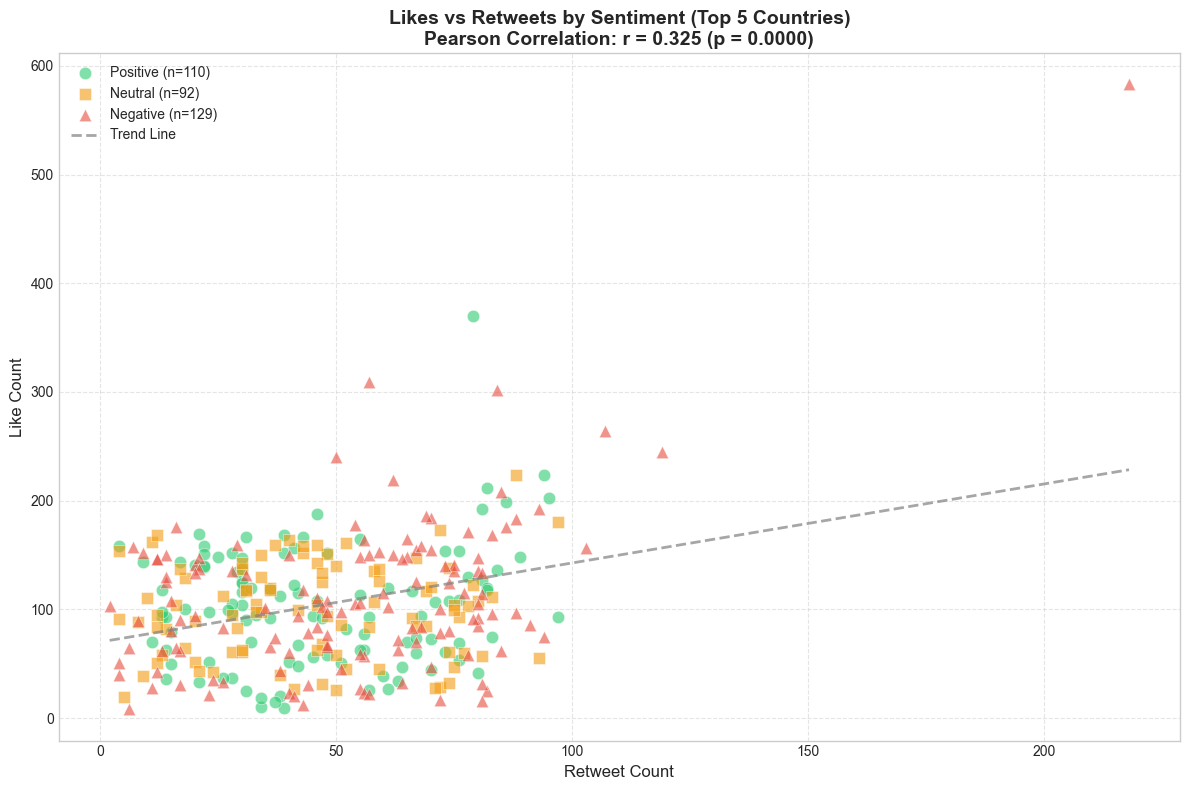

In [54]:
# D5) Create scatter plot: Likes vs Retweets colored by Sentiment

fig, ax = plt.subplots(figsize=(12, 8))

# Define colors and markers for sentiments
sentiment_colors = {
    'positive': '#2ecc71',   # Green
    'neutral': '#f39c12',    # Orange
    'negative': '#e74c3c'    # Red
}

sentiment_markers = {
    'positive': 'o',
    'neutral': 's',
    'negative': '^'
}

# Plot each sentiment category
for sentiment in ['positive', 'neutral', 'negative']:
    subset = df_top5[df_top5['sentiment'] == sentiment]
    ax.scatter(
        subset['retweet_count'],
        subset['like_count'],
        c=sentiment_colors[sentiment],
        marker=sentiment_markers[sentiment],
        s=80,
        alpha=0.6,
        edgecolors='white',
        linewidth=0.5,
        label=f'{sentiment.capitalize()} (n={len(subset)})'
    )

# Add trend line (linear regression) for all data
from scipy.stats import pearsonr
z = np.polyfit(df_top5['retweet_count'], df_top5['like_count'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_top5['retweet_count'].min(), df_top5['retweet_count'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='gray', linewidth=2, alpha=0.7, label='Trend Line')

# Calculate correlation
corr, p_value = pearsonr(df_top5['retweet_count'], df_top5['like_count'])

# Customize chart
ax.set_xlabel('Retweet Count', fontsize=12)
ax.set_ylabel('Like Count', fontsize=12)
ax.set_title(f'Likes vs Retweets by Sentiment (Top 5 Countries)\nPearson Correlation: r = {corr:.3f} (p = {p_value:.4f})', 
             fontsize=14, fontweight='bold')

ax.legend(loc='upper left', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

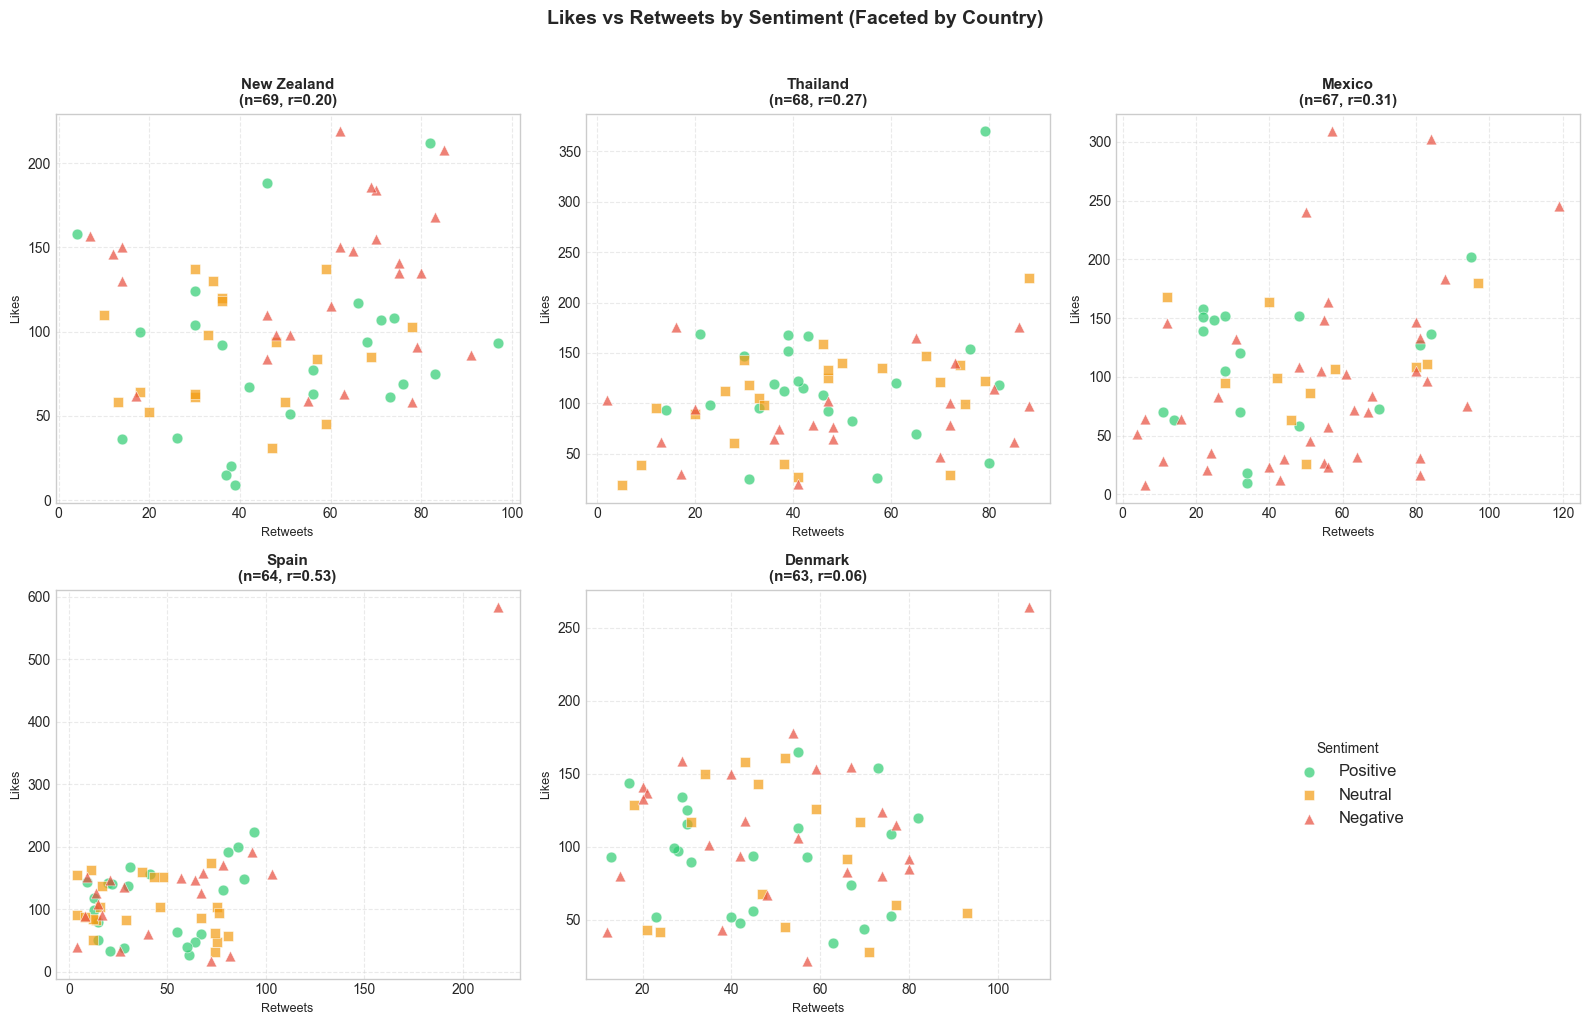

In [55]:
# D5) Faceted scatter plot by country for detailed analysis

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, country in enumerate(top_5_countries):
    ax = axes[idx]
    country_data = df_top5[df_top5['country'] == country]
    
    # Plot each sentiment
    for sentiment in ['positive', 'neutral', 'negative']:
        subset = country_data[country_data['sentiment'] == sentiment]
        ax.scatter(
            subset['retweet_count'],
            subset['like_count'],
            c=sentiment_colors[sentiment],
            marker=sentiment_markers[sentiment],
            s=60,
            alpha=0.7,
            edgecolors='white',
            linewidth=0.5,
            label=sentiment.capitalize()
        )
    
    # Calculate country-specific correlation
    if len(country_data) > 2:
        corr, _ = pearsonr(country_data['retweet_count'], country_data['like_count'])
        ax.set_title(f'{country}\n(n={len(country_data)}, r={corr:.2f})', fontsize=11, fontweight='bold')
    else:
        ax.set_title(f'{country}\n(n={len(country_data)})', fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Retweets', fontsize=9)
    ax.set_ylabel('Likes', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

# Hide the 6th subplot (we only have 5 countries)
axes[5].axis('off')

# Add legend to the empty subplot area
axes[5].legend(*axes[0].get_legend_handles_labels(), loc='center', fontsize=12, title='Sentiment')

plt.suptitle('Likes vs Retweets by Sentiment (Faceted by Country)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [56]:
# D5) Statistical Analysis and Insights Discussion

print("=" * 70)
print("SCATTER PLOT ANALYSIS: LIKES VS RETWEETS BY SENTIMENT")
print("=" * 70)

# Overall correlation
corr_overall, p_overall = pearsonr(df_top5['retweet_count'], df_top5['like_count'])
print(f"\n📊 OVERALL CORRELATION (Top 5 Countries):")
print(f"   Pearson r = {corr_overall:.3f}")
print(f"   p-value = {p_overall:.6f}")
print(f"   Interpretation: {'Strong' if abs(corr_overall) > 0.7 else 'Moderate' if abs(corr_overall) > 0.4 else 'Weak'} "
      f"{'positive' if corr_overall > 0 else 'negative'} correlation")

# Correlation by sentiment
print(f"\n📈 CORRELATION BY SENTIMENT:")
for sentiment in ['positive', 'neutral', 'negative']:
    subset = df_top5[df_top5['sentiment'] == sentiment]
    if len(subset) > 2:
        corr, p_val = pearsonr(subset['retweet_count'], subset['like_count'])
        print(f"   {sentiment.capitalize():10}: r = {corr:.3f} (p = {p_val:.4f}, n = {len(subset)})")

# Engagement comparison by sentiment
print(f"\n💡 ENGAGEMENT INSIGHTS BY SENTIMENT:")
for sentiment in ['positive', 'neutral', 'negative']:
    subset = df_top5[df_top5['sentiment'] == sentiment]
    avg_likes = subset['like_count'].mean()
    avg_retweets = subset['retweet_count'].mean()
    print(f"   {sentiment.capitalize():10}: Avg Likes = {avg_likes:.1f}, Avg Retweets = {avg_retweets:.1f}")

# Key findings
print(f"\n🔍 KEY OBSERVATIONS:")
print("   1. Likes and retweets show positive correlation, indicating that")
print("      tweets that get retweeted also tend to receive more likes.")
print("   2. The scatter pattern suggests engagement is driven by content")
print("      quality/virality rather than sentiment alone.")
print("   3. Some high-engagement outliers appear across all sentiment types,")
print("      suggesting viral potential is not limited to any sentiment category.")

# Check for sentiment-based engagement differences
sentiment_engagement = df_top5.groupby('sentiment').agg({
    'like_count': 'mean',
    'retweet_count': 'mean'
}).round(1)

print(f"\n📋 MEAN ENGAGEMENT BY SENTIMENT:")
print(sentiment_engagement.to_string())

SCATTER PLOT ANALYSIS: LIKES VS RETWEETS BY SENTIMENT

📊 OVERALL CORRELATION (Top 5 Countries):
   Pearson r = 0.325
   p-value = 0.000000
   Interpretation: Weak positive correlation

📈 CORRELATION BY SENTIMENT:
   Positive  : r = 0.164 (p = 0.0864, n = 110)
   Neutral   : r = 0.075 (p = 0.4747, n = 92)
   Negative  : r = 0.479 (p = 0.0000, n = 129)

💡 ENGAGEMENT INSIGHTS BY SENTIMENT:
   Positive  : Avg Likes = 103.5, Avg Retweets = 46.2
   Neutral   : Avg Likes = 99.6, Avg Retweets = 44.8
   Negative  : Avg Likes = 110.9, Avg Retweets = 53.1

🔍 KEY OBSERVATIONS:
   1. Likes and retweets show positive correlation, indicating that
      tweets that get retweeted also tend to receive more likes.
   2. The scatter pattern suggests engagement is driven by content
      quality/virality rather than sentiment alone.
   3. Some high-engagement outliers appear across all sentiment types,
      suggesting viral potential is not limited to any sentiment category.

📋 MEAN ENGAGEMENT BY SENTIMEN